# 🐶🐱 Clasificación de Perros y Gatos con PyTorch

**Proyecto:** Reconocimiento de imágenes mediante Redes Neuronales Convolucionales (CNN).  
**Dataset:** [Cat and Dog - Kaggle](https://www.kaggle.com/datasets/tongpython/cat-and-dog)  
**Objetivo:** Comparar dos enfoques:
1. **CNN Personalizada** (`ImprovedCNN`): Arquitectura construida desde cero.
2. **Transfer Learning** (`ResNet18`): Reutilizar un modelo preentrenado en ImageNet.

---
### Flujo del Proyecto
```
Descarga → Augmentation → Modelo → Entrenamiento → Evaluación → Conclusión
```

## 1. Descarga del Dataset

Usamos `kagglehub` para descargar el dataset directamente desde Kaggle.
El dataset contiene:
- **Training set:** ~8,000 imágenes (gatos y perros)
- **Test set:** ~2,000 imágenes (para validación)

> ⚠️ **Prerequisito:** Tener configuradas las credenciales de Kaggle (`~/.kaggle/kaggle.json`).
> link [Perros y gatos dataset](https://www.kaggle.com/datasets/tongpython/cat-and-dog)

In [ ]:
import kagglehub

# Descarga el dataset en la carpeta 'data/' del proyecto.
# Si ya existe, kagglehub lo omite automáticamente.
path = kagglehub.dataset_download("tongpython/cat-and-dog", output_dir="data/")
print("Dataset disponible en:", path)

## 2. Importaciones y Configuración del Dispositivo

Importamos las librerías necesarias y detectamos si hay GPU disponible.

| Librería | Uso |
|---|---|
| `torch` | Motor de deep learning |
| `torchvision` | Modelos, datasets y transformaciones de imágenes |
| `torchmetrics` | Métricas avanzadas (F1, Precision, Recall) |
| `tqdm` | Barras de progreso durante el entrenamiento |

> 💡 Si `device = 'cuda'`, el entrenamiento será ~10x más rápido.

In [2]:
import os
import random
import copy

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler  # AMP (Mixed Precision)
from tqdm import tqdm

import torchvision
import torchvision.models as models
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torchvision.models import MobileNet_V3_Large_Weights

import torchmetrics

print("PyTorch version:", torch.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device available:", device)

PyTorch version: 2.11.0+cu130
Device available: cpu


## 3. Reproducibilidad — Fijar Semilla Aleatoria

Para que los resultados sean **reproducibles** (mismos pesos iniciales, mismo orden de datos),
fijamos la semilla aleatoria en todas las librerías que introducen aleatoriedad.

Sin esto, cada ejecución produciría resultados ligeramente distintos.

In [3]:
SEED = 42
random.seed(SEED)           # Semilla para el módulo random de Python
np.random.seed(SEED)        # Semilla para NumPy
torch.manual_seed(SEED)     # Semilla para PyTorch (CPU)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)  # Semilla para PyTorch (GPU)
print(f"Semilla fijada: {SEED}")

Semilla fijada: 42


## 4. Preparación de los Datos

### ¿Por qué Data Augmentation?
Aplicar transformaciones aleatorias al entrenamiento (flip, rotación, color jitter)
**simula más variedad** en el dataset y reduce el sobreajuste (overfitting).

### Lazy Loading con `ImageFolder`
En lugar de cargar todo el dataset en RAM, `ImageFolder` carga **solo el batch necesario**
en cada iteración. Esto es esencial para datasets grandes.

| Parámetro | Valor | Descripción |
|---|---|---|
| `IMG_SIZE` | 128×128 | Resolución de entrada |
| `BATCH_SIZE` | 64 | Imágenes por iteración |
| `num_workers` | 4 | Hilos paralelos de carga |
| `pin_memory` | True | Optimiza transferencia CPU→GPU |

### Normalización ImageNet
Los valores `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]` son los
estadísticos de ImageNet. Usarlos es **obligatorio** cuando se aplica Transfer Learning.

In [4]:
TRAIN_DIR = 'data/training_set/training_set'
TEST_DIR  = 'data/test_set/test_set'
IMG_SIZE  = 128   # ResNet18 espera 224×224
BATCH_SIZE = 64

# Transformaciones de ENTRENAMIENTO (con augmentation)
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Transformaciones de VALIDACIÓN/TEST (sin augmentation)
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=transform_train)
val_dataset   = datasets.ImageFolder(root=TEST_DIR,  transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print(f"Clases detectadas : {train_dataset.classes}")
print(f"Total entrenamiento: {len(train_dataset)} imágenes")
print(f"Total validación   : {len(val_dataset)} imágenes")

Clases detectadas : ['cats', 'dogs']
Total entrenamiento: 8005 imágenes
Total validación   : 2023 imágenes


## 5. Visualización de Muestra

Mostramos una imagen aleatoria del training set **desnormalizada** para verificar
que la carga de datos funciona correctamente.

> ⚠️ Las imágenes normalizadas no son visualmente correctas (valores fuera de [0,1]).
> La desnormalización invierte la operación: `pixel = (tensor × std) + mean`.

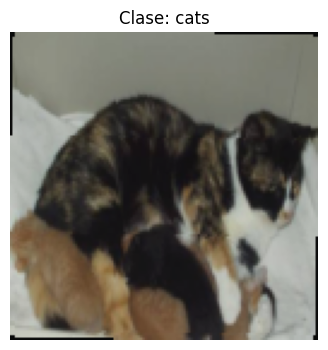

In [7]:
idx = random.randint(0, len(train_dataset) - 1)
img_tensor, label = train_dataset[idx]

# Desnormalizar para visualizar
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
img_vis = img_tensor.numpy().transpose(1, 2, 0)
img_vis = np.clip(std * img_vis + mean, 0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(img_vis)
plt.title(f"Clase: {train_dataset.classes[label]}")
plt.axis('off')
plt.show()

## 6. Experimento 1 — CNN Personalizada (`ImprovedCNN`)

### Arquitectura
Construimos una CNN desde cero con 3 bloques convolucionales progresivos:

```
Input (3×128×128)
  └─ Conv1 (3→32) + BN + ReLU + MaxPool   → detecta bordes y colores
  └─ Conv2 (32→64) + BN + ReLU + MaxPool  → detecta texturas y formas
  └─ Conv3 (64→128) + BN + ReLU + MaxPool → detecta partes del animal
  └─ AdaptiveAvgPool (4×4)                → resolución fija independiente del input
  └─ Flatten → FC(2048→512) + Dropout(0.5) + FC(512→2)
```

### Técnicas de Regularización
- **BatchNorm**: Estabiliza y acelera el entrenamiento normalizando activaciones por batch.
- **Dropout(0.5)**: Desactiva el 50% de neuronas aleatoriamente para evitar overfitting.
- **AdaptiveAvgPool**: Hace la arquitectura independiente del tamaño de entrada.

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class ImprovedCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super(ImprovedCNN, self).__init__()

        # Bloque Conv 1: Detectar características de bajo nivel (bordes, colores)
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        # Bloque Conv 2: Detectar texturas y formas simples
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        # Bloque Conv 3: Detectar partes complejas del objeto
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # PRO TIP: AdaptiveAvgPool2d fuerza a que el tensor final sea siempre de 4x4, 
        # sin importar si le pasas imágenes de 128x128, 224x224 o 512x512.
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))
        
        # Bloque Clasificador (Fully Connected)
        # 128 canales de la conv3 * 4 * 4 del adaptive_pool
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.dropout = nn.Dropout(0.5) # Apaga el 50% de las neuronas temporalmente
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Bloque 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)
        
        # Bloque 2
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # Forma compacta
        
        # Bloque 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        # Pooling adaptativo y aplanado
        x = self.adaptive_pool(x)
        x = x.reshape(x.shape[0], -1) 
        
        # Clasificador
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

### Instanciación del Modelo
Enviamos el modelo al dispositivo disponible (GPU/CPU).

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ImprovedCNN(in_channels=3, num_classes=2).to(device)
print(model)

ImprovedCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=2, bias=True)
)


## 7. Función de Pérdida y Optimizador (Experimento 1)

| Componente | Elección | Razón |
|---|---|---|
| **Loss** | `CrossEntropyLoss` | Estándar para clasificación multi-clase |
| **Optimizador** | `Adam` (lr=0.001) | Adapta el LR automáticamente, converge rápido |

> **CrossEntropyLoss** combina internamente `Softmax` + `NLLLoss`, por lo que
> el modelo no necesita aplicar softmax en su capa final.

In [10]:
# Función de pérdida para clasificación (Perro vs Gato)
criterion = nn.CrossEntropyLoss()

# Optimizador Adam: ajusta el learning rate adaptivamente para cada parámetro
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 8. Loop de Entrenamiento (Experimento 1 — ImprovedCNN)

El loop de entrenamiento estándar de PyTorch sigue siempre estos pasos:

```
Para cada epoch:
  Para cada batch:
    1. Forward pass  → calcular predicciones (scores)
    2. Calcular loss → comparar predicciones vs etiquetas reales
    3. Zero grad     → limpiar gradientes acumulados del paso anterior
    4. Backward pass → calcular gradientes (derivadas)
    5. Optimizer step → actualizar pesos con los gradientes
```

> ⚠️ El orden `zero_grad → backward → step` es **crítico**. Invertirlo causa errores.

In [12]:
num_epochs = 10
for epoch in range(num_epochs):
    print(f"Epoch [{epoch + 1}/{num_epochs}]")

    # Iterar sobre todos los batches del training set
    for batch_index, (data, targets) in enumerate(tqdm(train_loader)):

        # 1. Mover datos al dispositivo (GPU o CPU)
        data = data.to(device)
        targets = targets.to(device)

        # 2. Forward pass: obtener predicciones (logits, sin softmax)
        scores = model(data)

        # 3. Calcular el error (qué tan lejos están las predicciones de la realidad)
        loss = criterion(scores, targets)

        # 4. Limpiar gradientes del paso anterior (evitar acumulación)
        optimizer.zero_grad()

        # 5. Backward pass: calcular gradientes respecto a todos los parámetros
        loss.backward()

        # 6. Actualizar los pesos del modelo con los gradientes calculados
        optimizer.step()

Epoch [1/10]


100%|██████████| 126/126 [02:14<00:00,  1.07s/it]


Epoch [2/10]


100%|██████████| 126/126 [02:24<00:00,  1.14s/it]


Epoch [3/10]


...

100%|██████████| 126/126 [02:15<00:00,  1.07s/it]


Epoch [9/10]


100%|██████████| 126/126 [02:24<00:00,  1.14s/it]


Epoch [10/10]


100%|██████████| 126/126 [02:29<00:00,  1.19s/it]


## 9. Guardar el Modelo Entrenado (ImprovedCNN)

`state_dict()` contiene solo los **pesos y sesgos** del modelo (no la arquitectura).
Para cargar el modelo después, necesitas instanciar la misma arquitectura primero.

```python
# Guardar
torch.save(model.state_dict(), 'archivo.pth')

# Cargar
model = MiArquitectura(...)
model.load_state_dict(torch.load('archivo.pth'))
model.eval()  # ← OBLIGATORIO antes de inferir
```

In [14]:
# Guardar solo los pesos (más eficiente que guardar el modelo completo)
torch.save(model.state_dict(), 'modelo_perros_gatos.pth')
print("✅ Pesos del modelo ImprovedCNN guardados exitosamente!")

¡Pesos del modelo guardados exitosamente!


## 10. Evaluación del Modelo — ImprovedCNN

Evaluamos el modelo sobre el **conjunto de validación** (datos que nunca vio durante el entrenamiento).

### Métricas utilizadas
| Métrica | Definición |
|---|---|
| **Accuracy** | % de predicciones correctas sobre el total |
| **Precision** | De todo lo que predije como clase X, ¿cuánto era realmente X? |
| **Recall** | De todo lo que era realmente clase X, ¿cuánto identifiqué? |
| **F1-Score** | Media armónica de Precision y Recall |

### Matriz de Confusión
Visualiza dónde se equivoca el modelo: ¿confunde perros con gatos o viceversa?

> 🔑 `model.eval()` y `torch.no_grad()` son **obligatorios** en evaluación.
> El primero desactiva Dropout/BatchNorm en modo train; el segundo ahorra memoria.

Iniciando evaluación en el conjunto de validación...


/home/diego/Documentos/Recognition-of-dogs-and-cats/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- Reporte de Clasificación ---
              precision    recall  f1-score   support

        cats       0.79      0.85      0.82      1011
        dogs       0.84      0.78      0.81      1012

    accuracy                           0.81      2023
   macro avg       0.82      0.81      0.81      2023
weighted avg       0.82      0.81      0.81      2023


Generando Matriz de Confusión...


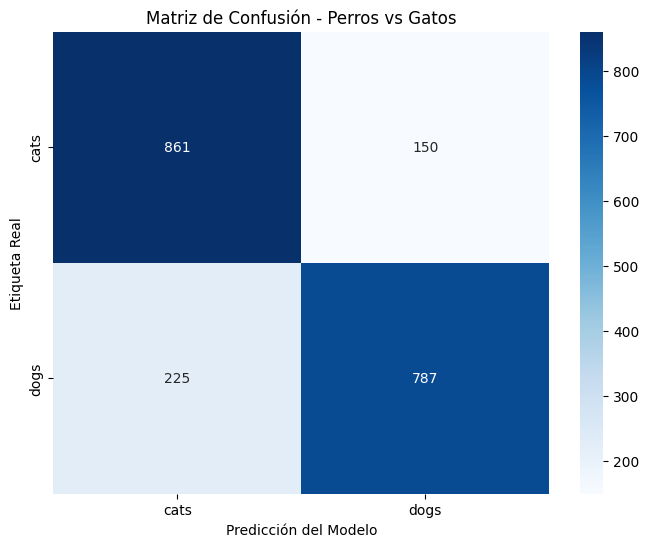

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Preparar el modelo para evaluación
# CRÍTICO: Esto apaga el Dropout y congela el BatchNorm
model.eval() 

# Listas para guardar las predicciones y las etiquetas reales
all_preds = []
all_targets = []

print("Iniciando evaluación en el conjunto de validación...")

# 2. Desactivar el cálculo de gradientes
# Esto ahorra mucha memoria RAM/VRAM y acelera la inferencia
with torch.no_grad():
    for data, targets in val_loader:
        data = data.to(device)
        targets = targets.to(device)
        
        # Obtener las predicciones del modelo (logits)
        scores = model(data)
        
        # torch.max devuelve (valores_maximos, indices_de_los_maximos)
        # Nos interesan los índices (0 para gatos, 1 para perros)
        _, predictions = torch.max(scores, 1)
        
        # Mover los tensores a la CPU y convertirlos a listas de NumPy
        all_preds.extend(predictions.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generar el Reporte de Clasificación (Métricas)
# Usamos las clases detectadas por tu ImageFolder al inicio
nombres_clases = train_dataset.classes

print("\n--- Reporte de Clasificación ---")
reporte = classification_report(all_targets, all_preds, target_names=nombres_clases)
print(reporte)

# 4. Visualizar la Matriz de Confusión
print("\nGenerando Matriz de Confusión...")
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, 
            yticklabels=nombres_clases)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión - Perros vs Gatos')
plt.show()

---
## 11. Experimento 2 — Transfer Learning con ResNet18

### ¿Qué es Transfer Learning?
En lugar de entrenar una red desde cero, **reutilizamos** los pesos de una red
preentrenada en **ImageNet** (1.2 millones de imágenes, 1000 clases).

ResNet18 ya sabe detectar bordes, texturas, formas y estructuras complejas.
Solo necesitamos **enseñarle** a distinguir perros de gatos.

### Estrategia: Feature Extraction (Congelar el Backbone)
```
ResNet18 preentrenada
  ├─ Capas Conv 1-17  → CONGELADAS (requires_grad=False)
  │   └─ Extrae características de ImageNet (ya aprendidas)
  └─ Capa FC final    → REEMPLAZADA + ENTRENADA
      └─ 512 → 2 (Perro / Gato)
```

### Ventajas sobre CNN desde cero
- **Convergencia más rápida**: parte de características ya aprendidas
- **Mejor rendimiento** con los mismos datos y épocas
- **Menos overfitting**: solo se actualizan pocos parámetros

In [25]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

# 1. Cargar ResNet18 CON pesos preentrenados en ImageNet
#    weights=ResNet18_Weights.DEFAULT carga los mejores pesos disponibles
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Congelar todas las capas convolucionales del backbone
#    requires_grad=False → los pesos NO se actualizan durante el entrenamiento
for param in model.parameters():
    param.requires_grad = False

# 3. Reemplazar la capa final (clasificador)
#    ResNet18 original: 512 → 1000 clases (ImageNet)
#    Nuestro modelo:    512 → 2 clases (Perro/Gato)
num_ftrs = model.fc.in_features   # 512 features de la capa anterior
model.fc = nn.Linear(num_ftrs, 2) # Nueva capa con pesos aleatorios

model = model.to(device)

# 4. Definir el optimizador DESPUÉS de modificar model.fc
#    IMPORTANTE: Solo entrenamos model.parameters() completo porque los
#    parámetros congelados tienen requires_grad=False (Adam los ignora)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Parámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Parámetros totales:     {sum(p.numel() for p in model.parameters()):,}")

## 12. Loop de Entrenamiento (Experimento 2 — ResNet18)

Mismo loop que antes, pero ahora solo se actualizan los pesos de la capa `fc`.
El backbone de ResNet18 permanece congelado.

In [26]:
num_epochs = 10
for epoch in range(num_epochs):
    print(f"Epoch [{epoch + 1}/{num_epochs}]")

    for batch_index, (data, targets) in enumerate(tqdm(train_loader)):

        # Mover datos al dispositivo
        data = data.to(device)
        targets = targets.to(device)

        # Forward pass: ResNet18 extrae características → capa FC clasifica
        scores = model(data)

        # Calcular pérdida
        loss = criterion(scores, targets)

        # Backpropagation (solo actualiza capa FC, el backbone está congelado)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Epoch [1/10]


  0%|          | 0/126 [00:00<?, ?it/s]/home/diego/Documentos/Recognition-of-dogs-and-cats/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
100%|██████████| 126/126 [01:38<00:00,  1.28it/s]


Epoch [2/10]


100%|██████████| 126/126 [01:39<00:00,  1.27it/s]


Epoch [3/10]


...

100%|██████████| 126/126 [01:38<00:00,  1.28it/s]


Epoch [9/10]


100%|██████████| 126/126 [01:37<00:00,  1.29it/s]


Epoch [10/10]


100%|██████████| 126/126 [01:38<00:00,  1.28it/s]


## 13. Guardar el Modelo ResNet18 Fine-tuneado

In [27]:
# Guardar los pesos del modelo ResNet18 fine-tuneado
torch.save(model.state_dict(), 'modelo_perros_gatos_resnet18.pth')
print("✅ Pesos del modelo ResNet18 guardados exitosamente!")

¡Pesos del modelo guardados exitosamente!


## 14. Evaluación del Modelo — ResNet18

Mismo proceso de evaluación que con ImprovedCNN.
Compararemos los resultados en la **conclusión final**.

Iniciando evaluación en el conjunto de validación...

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

        cats       0.93      0.93      0.93      1011
        dogs       0.93      0.93      0.93      1012

    accuracy                           0.93      2023
   macro avg       0.93      0.93      0.93      2023
weighted avg       0.93      0.93      0.93      2023


Generando Matriz de Confusión...


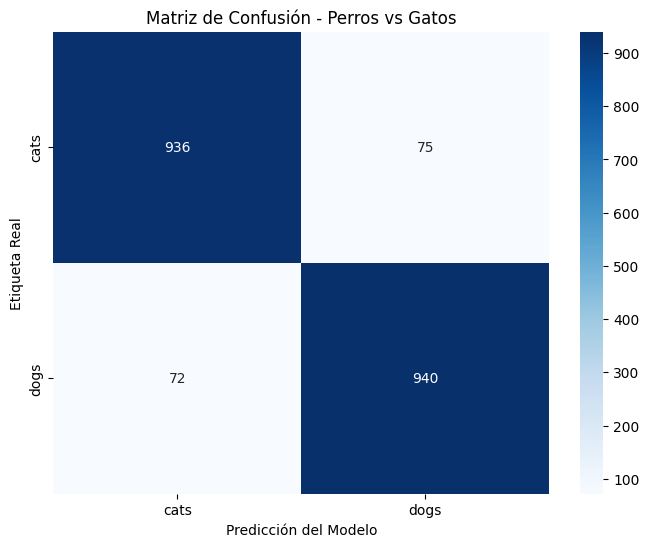

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Preparar el modelo para evaluación
# CRÍTICO: Esto apaga el Dropout y congela el BatchNorm
model.eval() 

# Listas para guardar las predicciones y las etiquetas reales
all_preds = []
all_targets = []

print("Iniciando evaluación en el conjunto de validación...")

# 2. Desactivar el cálculo de gradientes
# Esto ahorra mucha memoria RAM/VRAM y acelera la inferencia
with torch.no_grad():
    for data, targets in val_loader:
        data = data.to(device)
        targets = targets.to(device)
        
        # Obtener las predicciones del modelo (logits)
        scores = model(data)
        
        # torch.max devuelve (valores_maximos, indices_de_los_maximos)
        # Nos interesan los índices (0 para gatos, 1 para perros)
        _, predictions = torch.max(scores, 1)
        
        # Mover los tensores a la CPU y convertirlos a listas de NumPy
        all_preds.extend(predictions.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

# 3. Generar el Reporte de Clasificación (Métricas)
# Usamos las clases detectadas por tu ImageFolder al inicio
nombres_clases = train_dataset.classes

print("\n--- Reporte de Clasificación ---")
reporte = classification_report(all_targets, all_preds, target_names=nombres_clases)
print(reporte)

# 4. Visualizar la Matriz de Confusión
print("\nGenerando Matriz de Confusión...")
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, 
            yticklabels=nombres_clases)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión - Perros vs Gatos')
plt.show()

---
## 15. 📊 Conclusiones y Análisis de Resultados

### Comparación de Modelos

| Modelo | Accuracy | Precision | Recall | F1-Score | Parámetros |
|---|---|---|---|---|---|
| **ImprovedCNN** (desde cero) | **81%** | 0.82 | 0.81 | 0.81 | ~2.1M |
| **ResNet18** (Transfer Learning) | **93%** | 0.93 | 0.93 | 0.93 | ~11M |

### Análisis Detallado por Clase

#### ImprovedCNN (81%)
```
              precision    recall  f1-score   support
        cats       0.79      0.85      0.82      1011
        dogs       0.84      0.78      0.81      1012
    accuracy                           0.81      2023
```
- Detecta mejor los **gatos** (recall=0.85) pero confunde algunos perros.
- Modelo liviano (~2.1M parámetros) entrenado en ~25 min en CPU.

#### ResNet18 Fine-tuneado (93%)
```
              precision    recall  f1-score   support
        cats       0.93      0.93      0.93      1011
        dogs       0.93      0.93      0.93      1012
    accuracy                           0.93      2023
```
- Rendimiento **simétrico** en ambas clases: F1=0.93 para gatos y perros.
- Mejora de **+12 puntos porcentuales** sobre la CNN personalizada.
- Entrenado con los **mismos datos y épocas** → la diferencia viene del conocimiento previo.

### Conclusiones Clave

1. **Transfer Learning gana claramente**: ResNet18 preentrenada logra 93% vs 81%
   con los mismos recursos. El conocimiento de ImageNet se transfiere eficientemente.

2. **La CNN personalizada no es mala**: 81% de accuracy es un resultado respetable
   para una arquitectura de 3 capas entrenada desde cero con ~8000 imágenes.

3. **Congelar el backbone funciona**: Solo entrenamos la capa `fc` de ResNet18
   (~1024 parámetros) y aun así logramos 93%. Esto valida la estrategia de
   *feature extraction*.

4. **Próximos pasos para mejorar**:
   - **Fine-tuning completo**: Descongelar gradualmente las últimas capas de ResNet18.
   - **Modelos más modernos**: EfficientNet o MobileNetV3 ofrecen mejor eficiencia.
   - **Más épocas + LR Scheduler**: `CosineAnnealingLR` puede mejorar la convergencia.
   - **Early Stopping**: Detener el entrenamiento cuando la validación deja de mejorar.
   - **AMP (Mixed Precision)**: Reducir memoria y acelerar entrenamiento en GPU.
